### 1 Dimensional Motion

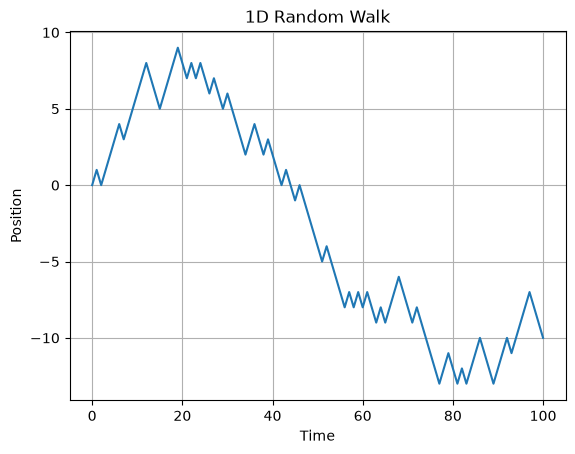

In [60]:
import numpy as np
import matplotlib.pyplot as plt

n_steps = 100

steps = np.random.choice([-1, 1], size=n_steps)
positions = np.insert(np.cumsum(steps), 0, 0)

time = np.arange(n_steps + 1)

plt.plot(time, positions)
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('1D Random Walk')
plt.grid()
plt.show()

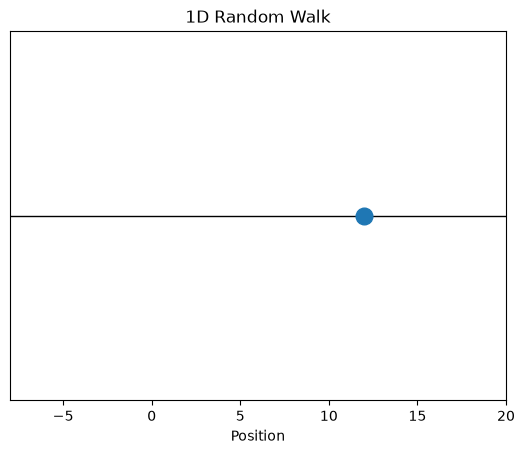

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create the figure
fig, ax = plt.subplots()

# Horizontal line
ax.axhline(0, color="black", linewidth=1)

# Position limits
ax.set_xlim(position.min() - 2, position.max() + 2)
ax.set_ylim(-1, 1)

ax.set_xlabel("Position")
ax.set_yticks([])
ax.set_title("1D Random Walk")

# Create the particle
particle, = ax.plot([], [], "o", markersize=12)


def update(frame):
    particle.set_data([position[frame]], [0])
    return particle,


# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(position),
    interval=50,
    blit=True
)

# Display animation inside the notebook
HTML(ani.to_jshtml())

### Multi-Particle Motion

In [77]:
import numpy as np

n_particles = 10_000
n_steps = 50

# Each entry is the step taken by one particle at one time
steps = np.random.choice(
    [-1, 1],
    size=(n_particles, n_steps)
)

# Position of every particle at every time
positions = np.zeros((n_particles, n_steps + 1))

positions[:, 1:] = np.cumsum(steps, axis=1)

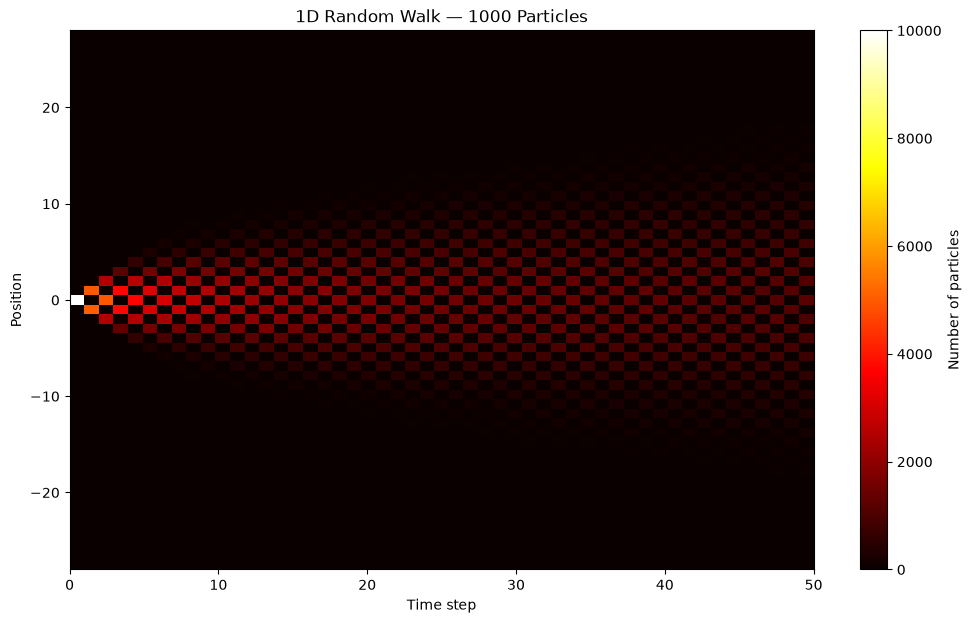

In [78]:
import matplotlib.pyplot as plt

# Count how many particles are at each position at each time
x_min = int(positions.min())
x_max = int(positions.max())

heatmap = np.zeros((x_max - x_min + 1, n_steps + 1))

for t in range(n_steps + 1):
    counts = np.bincount(
        positions[:, t].astype(int) - x_min,
        minlength=x_max - x_min + 1
    )
    
    heatmap[:, t] = counts

# Plot
plt.figure(figsize=(12, 7))

plt.imshow(
    heatmap,
    origin="lower",
    aspect="auto",
    extent=[0, n_steps, x_min, x_max],
    cmap="hot"
)

plt.colorbar(label="Number of particles")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.title("1D Random Walk — 1000 Particles")

plt.show()